In [53]:
# ============================================================
# 0) Imports + paramètres globaux 
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# --- Chemin vers la table (à adapter si besoin) ---
TABLE_PATH = "/Users/ethanada/Desktop/TGF05-TGH05.xls"

# --- Taille max du dataset selon l'énoncé ---
# (N doit être entre 1 et 1000)
N_DATASET = 1000

# --- Seed pour reproductibilité ---
SEED = 42
rng = np.random.default_rng(SEED)

In [55]:
# ============================================================
# 1) Chargement de la table TGF05 (format: lx par âge et génération)
# ============================================================


def load_tgf05_lx(path: str, sheet_name: str = "TGF05") -> pd.DataFrame:
    """
    Je lis la feuille TGF05 et je récupère lx sous forme:
    - index = âge
    - colonnes = génération (année de naissance)
    - valeurs = lx
    """
    raw = pd.read_excel(path, sheet_name=sheet_name, header=None)

    # Dans ce fichier: ligne 1 = en-têtes (Age + générations)
    header = raw.iloc[1].tolist()
    header[0] = "Age"

    df = raw.iloc[2:].copy()
    df.columns = header

    df = df.dropna(subset=["Age"])
    df["Age"] = df["Age"].astype(int)
    df = df.set_index("Age")

    # colonnes générations -> int (sinon parfois float)
    df.columns = [int(c) for c in df.columns]

    # valeurs numériques
    df = df.apply(pd.to_numeric, errors="coerce")

    return df


lx = load_tgf05_lx(TABLE_PATH, "TGF05")

print("lx shape:", lx.shape)
print("Age range:", lx.index.min(), "->", lx.index.max())
print("Generation range:", min(lx.columns), "->", max(lx.columns))
display(lx.head())

lx shape: (122, 106)
Age range: 0 -> 121
Generation range: 1900 -> 2005


,1900,1901,1902,1903,1904,1905,1906,1907,1908,1909,...,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005
Age,,,,,,,,,,,,,,,,,,,,,
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0
1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,99738.0,99739.0,99739.0,99740.0,99741.0,99742.0,99743.0,99743.0,99744.0,99745.0
2,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,99655.0,99656.0,99657.0,99658.0,99659.0,99660.0,99660.0,99661.0,99662.0,99663.0
3,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,99619.0,99620.0,99621.0,99622.0,99622.0,99623.0,99624.0,99625.0,99625.0,99626.0
4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,99598.0,99599.0,99600.0,99601.0,99602.0,99602.0,99603.0,99604.0,99605.0,99605.0


In [57]:
# ============================================================
# 2.1) Discount factor
# ============================================================

def v(i: float) -> float:
    """Facteur d'actualisation v = 1/(1+i)."""
    return 1.0 / (1.0 + i)

In [59]:
# ============================================================
# 2.2) À partir de lx, je calcule qx puis px = 1-qx
# ============================================================

def build_qx_from_lx(lx_df: pd.DataFrame) -> pd.DataFrame:
    qx_df = (lx_df - lx_df.shift(-1)) / lx_df

    # Dernier âge: je force qx=1 si lx>0 (convention simple)
    last_age = qx_df.index.max()
    qx_df.loc[last_age] = np.where(lx_df.loc[last_age] > 0, 1.0, 0.0)

    return qx_df.clip(0.0, 1.0)

qx = build_qx_from_lx(lx)
px = 1.0 - qx

display(qx.head())

,1900,1901,1902,1903,1904,1905,1906,1907,1908,1909,...,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005
Age,,,,,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.002620,0.002610,0.002610,0.002600,0.002590,0.002580,0.002570,0.002570,0.002560,0.002550
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000832,0.000832,0.000822,0.000822,0.000822,0.000822,0.000832,0.000822,0.000822,0.000822
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000361,0.000361,0.000361,0.000361,0.000371,0.000371,0.000361,0.000361,0.000371,0.000371
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000211,0.000211,0.000211,0.000211,0.000201,0.000211,0.000211,0.000211,0.000201,0.000211
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000141,0.000141,0.000141,0.000151,0.000151,0.000141,0.000141,0.000141,0.000151,0.000141


In [61]:
# ============================================================
# 2.3) Survie {}_t p_x = Π p_{x+k}
# ============================================================

def tpx(px_df: pd.DataFrame, age: int, gen: int, t: int) -> float:
    if t <= 0:
        return 1.0

    # Si on sort du domaine de la table, je renvoie 0 (pas de survie utilisable)
    if gen not in px_df.columns:
        return 0.0
    if age not in px_df.index or (age + t - 1) not in px_df.index:
        return 0.0

    p = 1.0
    for a in range(age, age + t):
        p *= float(px_df.loc[a, gen])
    return p

In [63]:
# ============================================================
# 2.4) Rente temporaire différée (annuity-immediate)
#     {}_{m'}a_{x:n} = Σ_{k=m'}^{m'+n-1} v^{k+1} * {}_k p_x
# ============================================================

def deferred_temp_annuity_immediate(px_df: pd.DataFrame, x: int, gen: int, m_prime: int, n: int, i: float) -> float:
    vv = v(i)
    s = 0.0
    for k in range(m_prime, m_prime + n):
        s += (vv ** (k + 1)) * tpx(px_df, x, gen, k)
    return s

In [65]:
# ============================================================
# 2.5) Prime unique nette
#     U = A * {}_{m'}a_{x:n}
# ============================================================

def single_premium(px_df: pd.DataFrame, x: int, gen: int, m_prime: int, n: int, i: float, A: float) -> float:
    return A * deferred_temp_annuity_immediate(px_df, x, gen, m_prime, n, i)

In [67]:
# ============================================================
# 2.6) Denominateur des primes: annuity-due temporaire
# ============================================================

def annuity_due_temp(px_df: pd.DataFrame, x: int, gen: int, m: int, i: float) -> float:
    vv = v(i)
    s = 0.0
    for j in range(0, m):
        s += (vv ** j) * tpx(px_df, x, gen, j)
    return s

In [69]:
# ============================================================
# 2.7) Prime annuelle nette
#     P = U / ä_{x:m}
# ============================================================

def annual_premium(px_df: pd.DataFrame, x: int, gen: int, m: int, m_prime: int, n: int, i: float, A: float) -> float:
    U = single_premium(px_df, x, gen, m_prime, n, i, A)
    denom = annuity_due_temp(px_df, x, gen, m, i)
    return U / denom if denom > 0 else np.nan

In [71]:
# ============================================================
# 2.8) Réserve prospective V_t
# ============================================================

def reserve_Vt(px_df: pd.DataFrame, x: int, gen: int, m: int, m_prime: int, n: int, i: float, A: float, t: int) -> float:
    vv = v(i)

    # --- PV des prestations futures à partir de t ---
    start_k = max(m_prime, t)
    end_k = m_prime + n - 1

    pv_b = 0.0
    for k in range(start_k, end_k + 1):
        # paiement en fin d'année (k+1), vu depuis t => v^{(k+1)-t}
        pv_b += (vv ** ((k + 1) - t)) * tpx(px_df, x + t, gen, k - t)
    pv_b *= A

    # --- PV des primes futures à partir de t (annuity-due) ---
    pv_p = 0.0
    if t < m:
        for j in range(t, m):
            pv_p += (vv ** (j - t)) * tpx(px_df, x + t, gen, j - t)

        P = annual_premium(px_df, x, gen, m, m_prime, n, i, A)
        pv_p *= (P if np.isfinite(P) else 0.0)

    return pv_b - pv_p

In [73]:
# ============================================================
# 2.9) Petit test rapide (je vérifie que ça sort des valeurs cohérentes)
# ============================================================

x = 23
m = 42
m_prime = 42
n = 34
i = 0.02
A = 2500

# Option 1: génération cohérente via issue_year - x
# Ici, je fixe issue_year=2025 juste pour le test
issue_year = 2025
gen = issue_year - x

U = single_premium(px, x, gen, m_prime, n, i, A)
P = annual_premium(px, x, gen, m, m_prime, n, i, A)
V0 = reserve_Vt(px, x, gen, m, m_prime, n, i, A, t=0)
V1 = reserve_Vt(px, x, gen, m, m_prime, n, i, A, t=1)

print("generation:", gen)
print("Single premium:", U)
print("Annual premium:", P)
print("V0:", V0, " | V1:", V1)

generation: 2002
Single premium: 24076.159562777466
Annual premium: 842.6477444942791
V0: 0.0  | V1: 859.6997440198829


In [75]:
# ============================================================
# 3) Génération du dataset (N <= 1000)
# ============================================================

X_VALUES  = [20, 30, 40, 50, 60]
M_VALUES  = [1, 5, 10, 20, 30, 40]
MP_VALUES = [0, 1, 5, 10, 20, 30, 40]
N_VALUES  = [1, 5, 10, 20, 30, 40, 50, 60]
I_VALUES  = [0.0, 0.005, 0.01, 0.015, 0.02, 0.025]
A_VALUES  = [50, 100, 200, 400, 800, 1000, 2000]

# Je choisis une plage de souscription raisonnable pour fabriquer des générations variées
ISSUE_YEAR_MIN = 1990
ISSUE_YEAR_MAX = 2025  # inclusif dans notre tirage

GEN_MIN = min(lx.columns)
GEN_MAX = max(lx.columns)

def sample_issue_year_for_x(x: int) -> int:
    """
    Je tire un issue_year tel que generation=issue_year-x soit dans la table.
    """
    y_min = max(ISSUE_YEAR_MIN, GEN_MIN + x)
    y_max = min(ISSUE_YEAR_MAX, GEN_MAX + x)
    if y_min > y_max:
        # cas extrême: je fallback sur une valeur "safe"
        return GEN_MAX + x
    return int(rng.integers(y_min, y_max + 1))

def generate_dataset(N: int) -> pd.DataFrame:
    rows = []
    for _ in range(N):
        x  = int(rng.choice(X_VALUES))
        m  = int(rng.choice(M_VALUES))
        mp = int(rng.choice(MP_VALUES))
        n  = int(rng.choice(N_VALUES))
        i  = float(rng.choice(I_VALUES))
        A  = float(rng.choice(A_VALUES))

        # génération cohérente (Option 1)
        issue_year = sample_issue_year_for_x(x)
        gen = issue_year - x

        # t : je couvre toute la durée de vie "utile" du contrat (0 -> mp+n)
        t = int(rng.integers(0, mp + n + 1))

        U = single_premium(px, x, gen, mp, n, i, A)
        P = annual_premium(px, x, gen, m, mp, n, i, A)
        Vt = reserve_Vt(px, x, gen, m, mp, n, i, A, t)

        rows.append({
            "x": x, "m": m, "m_prime": mp, "n": n, "i": i, "A": A,
            "issue_year": issue_year,  # utile pour traçabilité (optionnel en ML)
            "generation": gen,
            "t": t,
            "single_premium": U,
            "annual_premium": P,
            "reserve": Vt
        })

    df = pd.DataFrame(rows)
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    return df


df = generate_dataset(N_DATASET)
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (847, 12)


,x,m,m_prime,n,i,A,issue_year,generation,t,single_premium,annual_premium,reserve
1,30,1,10,60,0.020,1000.0,2015,1985,55,26588.889864,26588.889864,10563.128715
2,40,1,30,20,0.015,200.0,1996,1956,47,1883.254973,1883.254973,561.546581
3,50,20,5,50,0.015,400.0,2006,1956,12,10360.316443,607.108446,5210.979193
4,20,20,40,1,0.025,1000.0,1999,1979,26,352.239814,22.094972,676.158355
5,20,30,20,10,0.000,2000.0,2006,1986,27,19822.637013,663.818748,4004.675902


In [77]:
# ============================================================
# 3.1) Checks qualité (je vérifie rapidement que tout est ok)
# ============================================================

print("Missing values per column:")
print(df.isna().sum())

print("\nMin/Max single_premium:", df["single_premium"].min(), df["single_premium"].max())
print("Min/Max annual_premium:", df["annual_premium"].min(), df["annual_premium"].max())
print("Min/Max reserve:", df["reserve"].min(), df["reserve"].max())

print("\nAny negative single premiums?", (df["single_premium"] < 0).any())
print("Any negative annual premiums?", (df["annual_premium"] < 0).any())

Missing values per column:
x                 0
m                 0
m_prime           0
n                 0
i                 0
A                 0
issue_year        0
generation        0
t                 0
single_premium    0
annual_premium    0
reserve           0
dtype: int64

Min/Max single_premium: 3.4457915985203487 115025.61270695488
Min/Max annual_premium: 0.1750151514652489 100918.09190219498
Min/Max reserve: -11665.640101934545 85460.09788505829

Any negative single premiums? False
Any negative annual premiums? False


In [85]:
# ============================================================
# 4) Analyse du dataset (stats + graphes)
# ============================================================

display(df.describe())





,x,m,m_prime,n,i,A,issue_year,generation,t,single_premium,annual_premium,reserve
count,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000
mean,39.681228,17.062574,14.533648,26.839433,0.012544,666.706021,2009.578512,1969.897285,20.774498,10156.847794,2535.274982,4595.227017
std,14.391270,13.803488,13.822618,20.340255,0.008463,664.545482,9.016961,17.155459,18.849783,16057.497773,8486.473870,9698.686034
min,20.000000,1.000000,0.000000,1.000000,0.000000,50.000000,1995.000000,1935.000000,0.000000,3.445792,0.175015,-11665.640102
25%,30.000000,5.000000,1.000000,5.000000,0.005000,100.000000,2001.000000,1957.000000,5.000000,933.095128,86.875849,135.809641
50%,40.000000,10.000000,10.000000,20.000000,0.010000,400.000000,2010.000000,1970.000000,15.000000,3472.472508,392.156863,1121.939841
75%,50.000000,30.000000,30.000000,50.000000,0.020000,1000.000000,2017.000000,1983.000000,31.000000,11828.979438,1446.201894,4077.430252
max,60.000000,40.000000,40.000000,60.000000,0.025000,2000.000000,2025.000000,2005.000000,94.000000,115025.612707,100918.091902,85460.097885


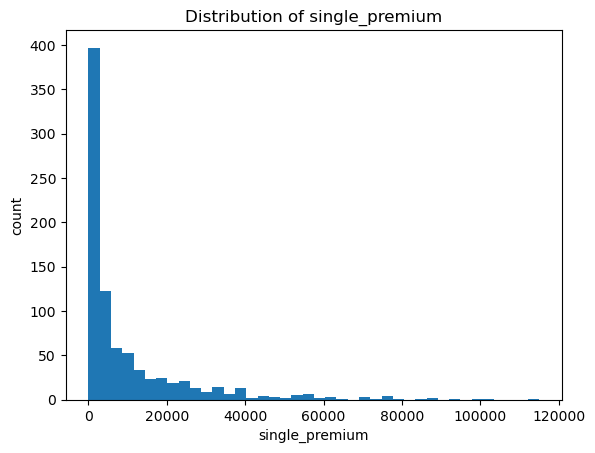

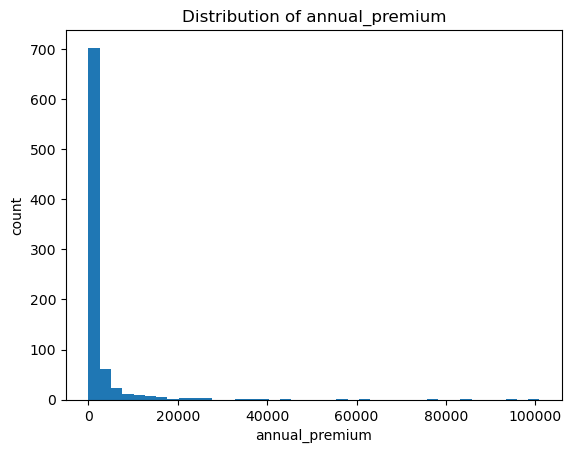

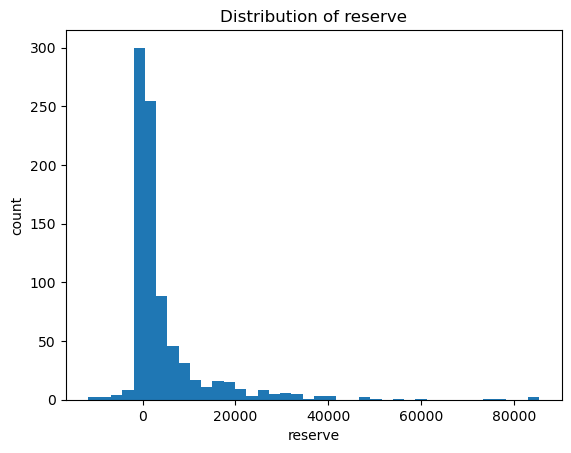

In [81]:
# Distributions des cibles
for col in ["single_premium", "annual_premium", "reserve"]:
    plt.figure()
    plt.hist(df[col], bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

,i,single_premium,annual_premium,reserve
0,0.000,13714.322690,2663.222113,5130.259454
1,0.005,14038.015120,4506.632974,6945.027555
2,0.010,9636.598412,2114.581677,4443.284710
3,0.015,10132.696455,2477.161639,3931.325599
4,0.020,7752.472078,2025.331166,3618.250517
5,0.025,5860.711074,1440.331629,3485.997956


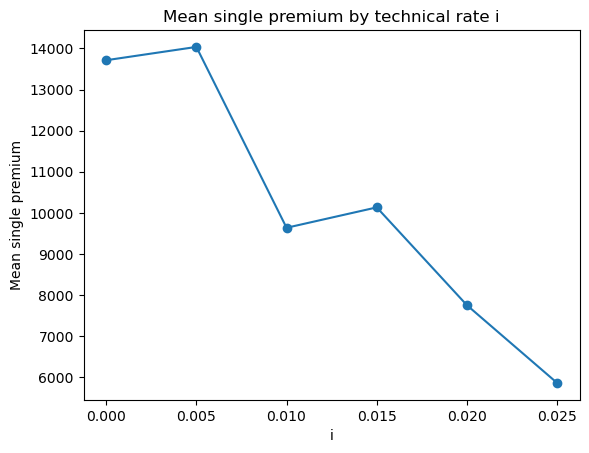

In [83]:
# Effet du taux i sur la prime unique (moyenne)
mean_by_i = df.groupby("i")[["single_premium", "annual_premium", "reserve"]].mean().reset_index()
display(mean_by_i)

plt.figure()
plt.plot(mean_by_i["i"], mean_by_i["single_premium"], marker="o")
plt.title("Mean single premium by technical rate i")
plt.xlabel("i")
plt.ylabel("Mean single premium")
plt.show()

In [87]:
# ============================================================
# 5) Preprocessing pour ML
# ============================================================

FEATURES = ["x", "m", "m_prime", "n", "i", "A", "generation", "t"]
# (Je peux garder issue_year, mais génération suffit; je le garde uniquement en trace)

X = df[FEATURES].copy()

In [91]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd


In [93]:
# ============================================================
# 6.1) Entraînement + évaluation (Ridge vs HGB) pour une target
# ============================================================

def evaluate_models_for_target(df: pd.DataFrame, X: pd.DataFrame, target: str, seed: int = 42) -> pd.DataFrame:
    y = df[target].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )

    # Baseline linéaire
    ridge = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=seed))
    ])

    # Modèle non-linéaire tabulaire
    hgb = HistGradientBoostingRegressor(random_state=seed)

    models = {"Ridge": ridge, "HGB": hgb}

    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, pred)
        mse = mean_squared_error(y_test, pred)
        rmse = float(np.sqrt(mse))
        r2 = r2_score(y_test, pred)

        results.append({
            "target": target,
            "model": name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

    return pd.DataFrame(results)

In [95]:
FEATURES = ["x", "m", "m_prime", "n", "i", "A", "generation", "t"]
X = df[FEATURES].copy()

In [97]:
scores_sp = evaluate_models_for_target(df, X, "single_premium", seed=SEED)
scores_ap = evaluate_models_for_target(df, X, "annual_premium", seed=SEED)
scores_rs = evaluate_models_for_target(df, X, "reserve", seed=SEED)

display(scores_sp)
display(scores_ap)
display(scores_rs)

,target,model,MAE,RMSE,R2
0,single_premium,Ridge,6474.851877,9566.965970,0.661871
1,single_premium,HGB,2098.070659,4785.803867,0.915386


,target,model,MAE,RMSE,R2
0,annual_premium,Ridge,3865.062869,9894.920514,0.215362
1,annual_premium,HGB,1487.879317,5757.883417,0.734313


,target,model,MAE,RMSE,R2
0,reserve,Ridge,4177.206428,7145.216711,0.470914
1,reserve,HGB,2688.479181,5840.238890,0.646527


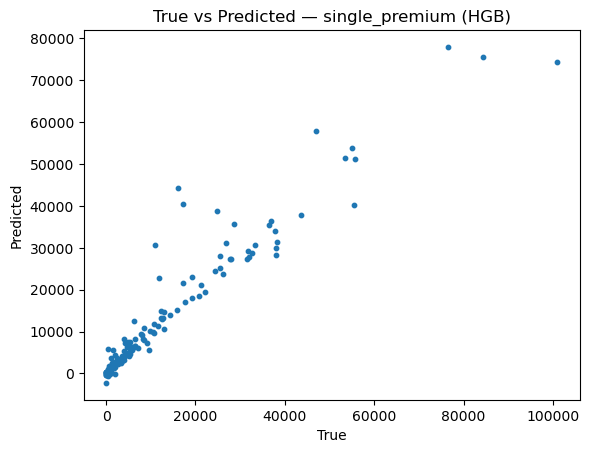

In [99]:
# ============================================================
# 6.3) Graph True vs Pred pour visualiser la qualité du fit
# ============================================================

import matplotlib.pyplot as plt

def true_vs_pred_plot(df: pd.DataFrame, X: pd.DataFrame, target: str, model_name: str = "HGB", seed: int = 42):
    y = df[target].copy()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

    if model_name == "Ridge":
        model = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0, random_state=seed))])
    else:
        model = HistGradientBoostingRegressor(random_state=seed)

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    plt.figure()
    plt.scatter(y_test, pred, s=10)
    plt.title(f"True vs Predicted — {target} ({model_name})")
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.show()

true_vs_pred_plot(df, X, "single_premium", "HGB", seed=SEED)

In [101]:
all_scores = pd.concat([scores_sp, scores_ap, scores_rs], ignore_index=True)
best = all_scores.sort_values(["target", "R2"], ascending=[True, False]).groupby("target").head(1)
display(all_scores)
display(best)

,target,model,MAE,RMSE,R2
0,single_premium,Ridge,6474.851877,9566.965970,0.661871
1,single_premium,HGB,2098.070659,4785.803867,0.915386
2,annual_premium,Ridge,3865.062869,9894.920514,0.215362
3,annual_premium,HGB,1487.879317,5757.883417,0.734313
4,reserve,Ridge,4177.206428,7145.216711,0.470914
5,reserve,HGB,2688.479181,5840.238890,0.646527


,target,model,MAE,RMSE,R2
3,annual_premium,HGB,1487.879317,5757.883417,0.734313
5,reserve,HGB,2688.479181,5840.238890,0.646527
1,single_premium,HGB,2098.070659,4785.803867,0.915386


In [107]:
# ============================================================
# Learning curve robuste 
# ============================================================

def learning_curve_hgb(df: pd.DataFrame, features: list, target: str, sizes: list, seed: int = 42):
    
    results = []
    max_N = len(df)
    
    for N in sizes:
        
        if N > max_N:
            print(f"Skipping N={N} (dataset only has {max_N} rows)")
            continue
        
        df_sub = df.sample(n=N, random_state=seed)
        
        X = df_sub[features]
        y = df_sub[target]
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=seed
        )
        
        model = HistGradientBoostingRegressor(random_state=seed)
        model.fit(X_train, y_train)
        
        pred = model.predict(X_test)
        r2 = r2_score(y_test, pred)
        
        results.append({"N": N, "R2": r2})
    
    return pd.DataFrame(results)

In [109]:
sizes = [50, 100, 200, 500, 1000]

lc_sp = learning_curve_hgb(df, FEATURES, "single_premium", sizes, seed=SEED)
lc_ap = learning_curve_hgb(df, FEATURES, "annual_premium", sizes, seed=SEED)
lc_rs = learning_curve_hgb(df, FEATURES, "reserve", sizes, seed=SEED)

display(lc_sp)
display(lc_ap)
display(lc_rs)

Skipping N=1000 (dataset only has 847 rows)
Skipping N=1000 (dataset only has 847 rows)
Skipping N=1000 (dataset only has 847 rows)


,N,R2
0,50,-0.350343
1,100,0.886937
2,200,0.432420
3,500,0.905264


,N,R2
0,50,-0.531373
1,100,0.374805
2,200,-2.084781
3,500,0.306208


,N,R2
0,50,-0.115286
1,100,0.553305
2,200,0.391389
3,500,0.730286


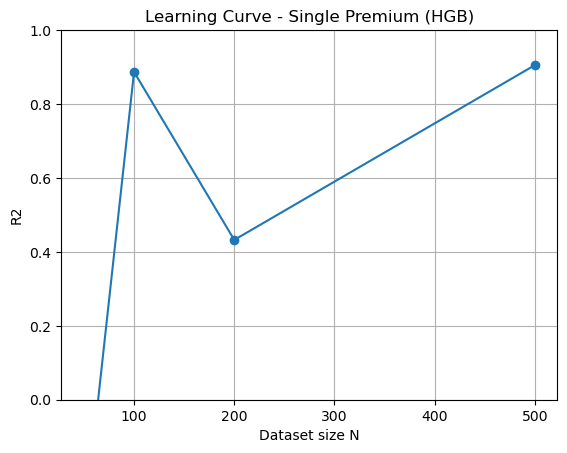

Saved to: figures_learning_curves/learning_curve_single_premium.png


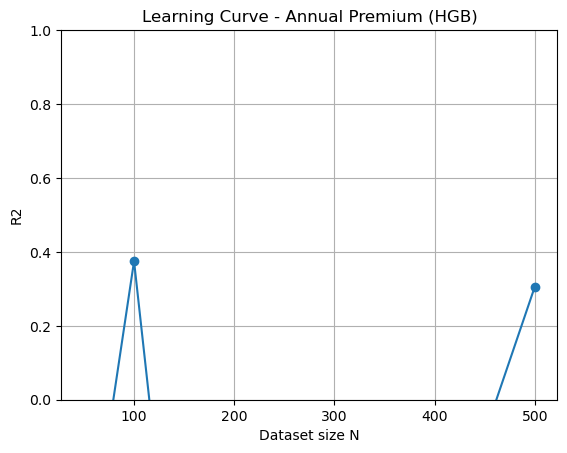

Saved to: figures_learning_curves/learning_curve_annual_premium.png


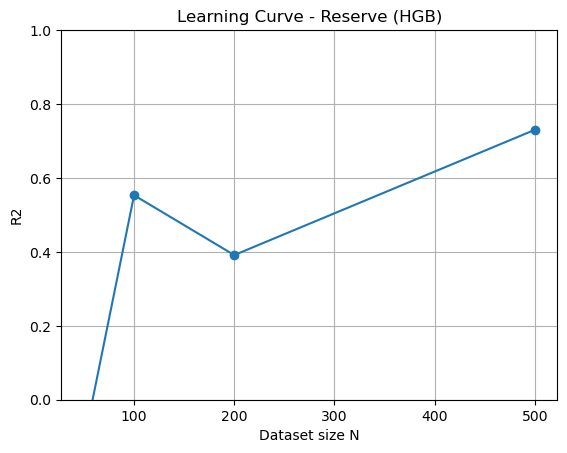

Saved to: figures_learning_curves/learning_curve_reserve.png


In [123]:
# ============================================================
# Learning curves + sauvegarde des figures
# ============================================================

import os

# dossier de sortie
OUTPUT_DIR = "figures_learning_curves"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def plot_and_save_learning_curve(lc_df, target_name, filename):
    
    plt.figure()
    plt.plot(lc_df["N"], lc_df["R2"], marker="o")
    plt.title(f"Learning Curve - {target_name} (HGB)")
    plt.xlabel("Dataset size N")
    plt.ylabel("R2")
    plt.ylim(0,1)
    plt.grid(True)
    
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print(f"Saved to: {path}")

# Sauvegarde des 3 courbes
plot_and_save_learning_curve(lc_sp, "Single Premium", "learning_curve_single_premium.png")
plot_and_save_learning_curve(lc_ap, "Annual Premium", "learning_curve_annual_premium.png")
plot_and_save_learning_curve(lc_rs, "Reserve", "learning_curve_reserve.png")

In [125]:
print("df shape:", df.shape)

df shape: (847, 12)


,feature,importance_mean,importance_std
5,A,1.156818,0.097151
3,n,0.789805,0.099795
2,m_prime,0.198532,0.055659
4,i,0.100932,0.019070
0,x,0.062726,0.024463
6,generation,0.011736,0.002004
1,m,-0.000410,0.000625
7,t,-0.007304,0.005321


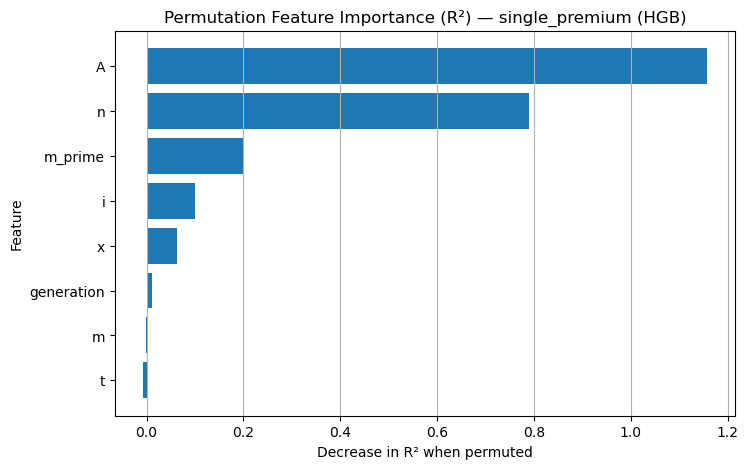

Saved to: figures_feature_importance/fi_single_premium.png


,feature,importance_mean,importance_std
1,m,0.756108,0.170734
5,A,0.614070,0.160790
3,n,0.362807,0.134112
4,i,0.047979,0.028861
2,m_prime,0.031855,0.025535
0,x,0.015704,0.014182
6,generation,0.000089,0.000700
7,t,-0.049561,0.035148


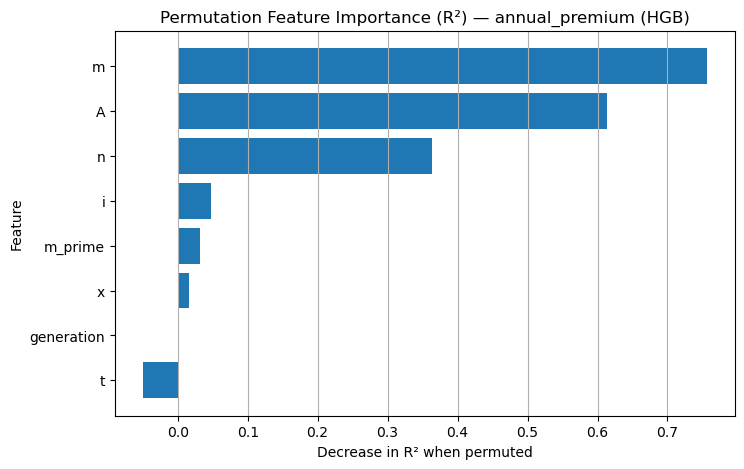

Saved to: figures_feature_importance/fi_annual_premium.png


,feature,importance_mean,importance_std
5,A,0.792083,0.203906
3,n,0.683845,0.127963
1,m,0.132061,0.044515
7,t,0.130154,0.046654
2,m_prime,0.079286,0.026344
0,x,0.062108,0.032925
4,i,0.052446,0.048675
6,generation,0.035921,0.014607


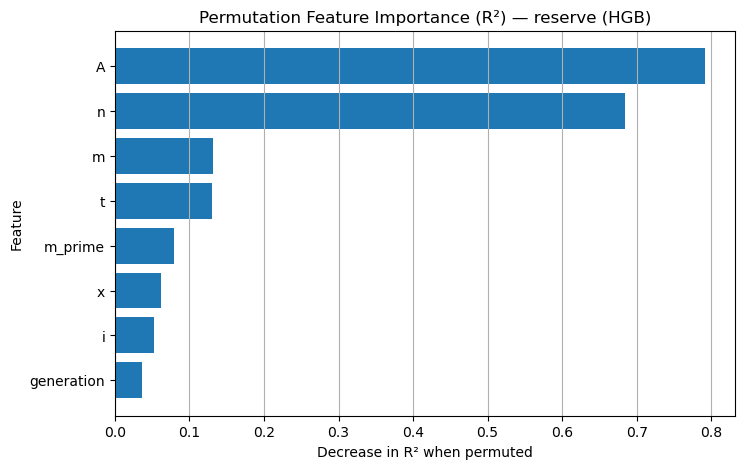

Saved to: figures_feature_importance/fi_reserve.png


In [127]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import os
import numpy as np

OUTPUT_DIR = "figures_feature_importance"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def fit_hgb_and_feature_importance(df, FEATURES, target, seed=42, n_repeats=10):
    # Split
    X = df[FEATURES].copy()
    y = df[target].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )

    # Modèle
    model = HistGradientBoostingRegressor(random_state=seed)
    model.fit(X_train, y_train)

    # Permutation importance sur le set de test
    perm = permutation_importance(
        model, X_test, y_test,
        n_repeats=n_repeats,
        random_state=seed,
        scoring="r2"
    )

    imp = pd.DataFrame({
        "feature": FEATURES,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False)

    return model, imp

def plot_importance_and_save(imp_df, target, filename):
    plt.figure(figsize=(8, 5))
    plt.barh(imp_df["feature"][::-1], imp_df["importance_mean"][::-1])
    plt.title(f"Permutation Feature Importance (R²) — {target} (HGB)")
    plt.xlabel("Decrease in R² when permuted")
    plt.ylabel("Feature")
    plt.grid(True, axis="x")

    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved to:", path)

# --- Single Premium ---
model_sp, imp_sp = fit_hgb_and_feature_importance(df, FEATURES, "single_premium", seed=SEED, n_repeats=10)
display(imp_sp)
plot_importance_and_save(imp_sp, "single_premium", "fi_single_premium.png")

# --- Annual Premium ---
model_ap, imp_ap = fit_hgb_and_feature_importance(df, FEATURES, "annual_premium", seed=SEED, n_repeats=10)
display(imp_ap)
plot_importance_and_save(imp_ap, "annual_premium", "fi_annual_premium.png")

# --- Reserve ---
model_rs, imp_rs = fit_hgb_and_feature_importance(df, FEATURES, "reserve", seed=SEED, n_repeats=10)
display(imp_rs)
plot_importance_and_save(imp_rs, "reserve", "fi_reserve.png")